In [4]:
import torch
import numpy as np


In [39]:
class FNN(torch.nn.Module):
    def __init__(self):
        super(FNN,self).__init__()
        self.hidden = torch.nn.Linear(1, 512)
        self.output = torch.nn.Linear(512, 1)
        self.relu = torch.nn.ReLU()
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [40]:
# 函数定义 y = sin(x) + 0.5\cos(2x)
x = np.linspace(-10, 10, 1000).reshape(-1, 1)
y = np.sin(x) + 0.5 * np.cos(2*x)

In [41]:
#数据采集 训练集（-10,10）中的随机800个点，测试集（-10,10）中的随机200个点
train_idx = np.random.choice(len(x), size=800, replace=False)
test_idx = np.array(list(set(range(len(x))) - set(train_idx)))

train_x = x[train_idx]
train_y = y[train_idx]
test_x = x[test_idx]
test_y = y[test_idx]

dataset = torch.utils.data.TensorDataset(torch.from_numpy(train_x).float(), torch.from_numpy(train_y).float())
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [42]:
# 模型训练
model = FNN()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
for epoch in range(2000):
    for batch_x, batch_y in dataloader:
        logits = model(batch_x)
        loss = torch.mean((logits - batch_y) ** 2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss {loss.item()}')

Epoch 0, Loss 0.7619330286979675
Epoch 0, Loss 45.884544372558594
Epoch 0, Loss 4.499626159667969
Epoch 0, Loss 10.280027389526367
Epoch 0, Loss 29.28044891357422
Epoch 0, Loss 14.215205192565918
Epoch 0, Loss 6.402414798736572
Epoch 0, Loss 1.418874740600586
Epoch 0, Loss 7.381908416748047
Epoch 0, Loss 22.771650314331055
Epoch 0, Loss 8.401997566223145
Epoch 0, Loss 2.9134361743927
Epoch 0, Loss 0.9283029437065125
Epoch 0, Loss 2.712177038192749
Epoch 0, Loss 7.170072078704834
Epoch 0, Loss 8.073195457458496
Epoch 0, Loss 4.150568962097168
Epoch 0, Loss 3.663235902786255
Epoch 0, Loss 1.4421019554138184
Epoch 0, Loss 2.8891122341156006
Epoch 0, Loss 2.9962735176086426
Epoch 0, Loss 3.021432638168335
Epoch 0, Loss 2.6087732315063477
Epoch 0, Loss 1.2704195976257324
Epoch 0, Loss 0.879694402217865
Epoch 100, Loss 0.1343558132648468
Epoch 100, Loss 0.2782176733016968
Epoch 100, Loss 0.1782781481742859
Epoch 100, Loss 0.1733056902885437
Epoch 100, Loss 0.19987286627292633
Epoch 100, Loss

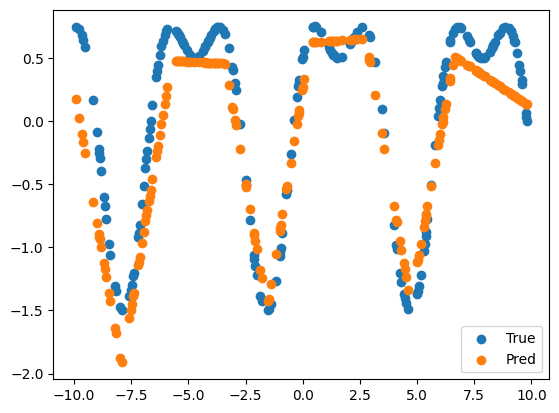

In [43]:

with torch.no_grad():
    pred_y = model(torch.from_numpy(test_x).float()).numpy()
# 可视化
import matplotlib.pyplot as plt
plt.scatter(test_x, test_y, label='True')
plt.scatter(test_x, pred_y, label='Pred')
plt.legend()
plt.show()